In [1]:
# Given a saved dataframe with all seeds and their corresponding policies, recover the latents

In [2]:
# do autoreload
%load_ext autoreload
%autoreload 2


In [7]:
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
torch.cuda.empty_cache()
pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stabilityai/sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [9]:
def get_latent_list_from_seeds(seeds: list[int]) -> list[Latent]:
    generators = [torch.Generator(device="cpu").manual_seed(seed) for seed in seeds]
    latents = [
            pipe.prepare_latents(
                batch_size=1,
                num_channels_latents=pipe.unet.config.in_channels,
                height=512,
                width=512,
                dtype=pipe.unet.dtype,
                device="cpu",
                generator=generator,
            )[0] / pipe.scheduler.init_noise_sigma
            for generator in generators
        ]
    return latents

In [6]:
# As an example, load in latent_alpha=0.75_10x10
import pandas as pd
example_df = pd.read_csv("results/latent_alpha=0.75_10x10/metrics.csv")
example_df["alpha"] = 0.75

In [5]:
# Each datapoint for a round is one winner image, and three/two non-winner images
from typing import NamedTuple
import torch

Latent = torch.Tensor # we'll represent as 3-dimensional, not 4-dimensional. We'll add the first dimension (batch size) only when needed.

class DataPoint(NamedTuple):
    round: int
    trial_id: str
    prompt_id: str
    alpha: float
    winner_latent: Latent
    loser_latents: list[Latent]

In [10]:
from generation.LatentSurvivalGenerator import LatentSurvivalGenerator
def get_data_point(df: pd.DataFrame, round: int, trial_id: str, prompt_id: str, alpha: float) -> tuple[DataPoint, DataPoint]:
    # 1. Filter Context
    rows = df[
        (df["trial_id"] == trial_id) & 
        (df["prompt_id"] == prompt_id) & 
        (df["alpha"] == alpha)
    ].sort_values("round")

    curr_rows = rows[rows["round"] == round]
    
    # Helper to fetch a single latent from a seed
    def get_latent(seed):
        return get_latent_list_from_seeds([seed])[0]

    # --- CASE 1: Round 0 (Base Case) ---
    if round == 0:
        winner_seed = curr_rows.loc[curr_rows["chosen"], "seed"].item()
        loser_seeds = curr_rows.loc[~curr_rows["chosen"], "seed"].tolist()

        return DataPoint(
            round, trial_id, prompt_id, alpha,
            get_latent(winner_seed),
            get_latent_list_from_seeds(loser_seeds)
        )

    # --- CASE 2: Round > 0 (Adaptation) ---
    
    # 2. Reconstruct the "King" (Winner) from Round 0 up to current Round - 1
    # Start with Round 0 winner
    r0_winner_seed = rows.loc[(rows["round"] == 0) & (rows["chosen"]), "seed"].item()
    king_latent = get_latent(r0_winner_seed)

    # Replay history: Filter for winners of previous rounds (1 to round-1)
    history_winners = rows[
        (rows["round"] > 0) & 
        (rows["round"] < round) & 
        (rows["chosen"])
    ]

    for _, row in history_winners.iterrows():
        # Only update if the winner wasn't simply carried over (reused)
        if not row["reused_from_previous"]:
            noise = get_latent(row["seed"])
            king_latent = LatentSurvivalGenerator.mix(running_latent=king_latent, noise=noise, alpha=alpha)

    # 3. Generate Latents for Current Round
    # Index 0 is always the existing King; 1-3 are the new Challengers
    latents_by_idx = {0: king_latent}
    
    challengers = curr_rows[(~curr_rows["reused_from_previous"]) & (curr_rows["image_idx"] > 0)]
    
    for _, row in challengers.iterrows():
        noise = get_latent(row["seed"])
        latents_by_idx[row["image_idx"]] = LatentSurvivalGenerator.mix(running_latent=king_latent, noise=noise, alpha=alpha)

    # 4. separate Winner vs Losers
    winner_idx = curr_rows.loc[curr_rows["chosen"], "image_idx"].item()
    
    # Construct final list of 4 to ensure correct indexing
    all_latents = [latents_by_idx[i] for i in range(4)]
    
    return DataPoint(
        round, trial_id, prompt_id, alpha,
        all_latents[winner_idx],                       # Winner
        [l for i, l in enumerate(all_latents) if i != winner_idx] # Losers
    )

In [ ]:
"""
prompt_id,trial_id,round,image_idx,image_path,user_score,chosen,prompt,seed,mean_pixel,reused_from_previous
009606-0136,trial0,0,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image0.png,1.0473462343215942,True,logo for a coffee chain,11396,0.43792152404785156,False
009606-0136,trial0,0,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image1.png,-0.5392330884933472,False,logo for a coffee chain,77398,0.7618764042854309,False
009606-0136,trial0,0,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image2.png,-0.1260194629430771,False,logo for a coffee chain,55303,0.5034304261207581,False
009606-0136,trial0,0,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round0/image3.png,1.003163456916809,False,logo for a coffee chain,4166,0.45758748054504395,False

009606-0136,trial0,1,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image0.png,1.0473462343215942,False,logo for a coffee chain,11396,0.43792152404785156,True
009606-0136,trial0,1,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image1.png,0.5898248553276062,False,logo for a coffee chain,3906,0.4530443847179413,False
009606-0136,trial0,1,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image2.png,1.1401515007019043,True,logo for a coffee chain,12281,0.5231702923774719,False
009606-0136,trial0,1,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round1/image3.png,-0.3460875153541565,False,logo for a coffee chain,28658,0.5631957054138184,False

009606-0136,trial0,2,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image0.png,1.1401515007019043,True,logo for a coffee chain,12281,0.5231702923774719,True
009606-0136,trial0,2,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image1.png,1.1303033828735352,False,logo for a coffee chain,30496,0.46017536520957947,False
009606-0136,trial0,2,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image2.png,0.2749439477920532,False,logo for a coffee chain,66238,0.6083332896232605,False
009606-0136,trial0,2,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round2/image3.png,0.8969414234161377,False,logo for a coffee chain,78908,0.5108384490013123,False

009606-0136,trial0,3,0,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image0.png,1.1401515007019043,True,logo for a coffee chain,12281,0.5231702923774719,True
009606-0136,trial0,3,1,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image1.png,0.9545550346374512,False,logo for a coffee chain,3479,0.45535197854042053,False
009606-0136,trial0,3,2,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image2.png,0.8592708110809326,False,logo for a coffee chain,73564,0.519206702709198,False
009606-0136,trial0,3,3,outputs/2025-12-03_23-57-00/images/009606-0136/trial0/round3/image3.png,-0.4301868975162506,False,logo for a coffee chain,26063,0.6521996855735779,False
"""

In [13]:
example_round = 0
example_trial_id = "trial9"
example_prompt_id="009606-0136"
example_alpha = 0.75

example_data_point = get_data_point(example_df, round=example_round, trial_id=example_trial_id, prompt_id=example_prompt_id, alpha=example_alpha)

# Get the prompt from the prompt id
example_prompt: str = example_df[example_df["prompt_id"] == example_prompt_id]["prompt"].unique().item()

  0%|          | 0/1 [00:00<?, ?it/s]

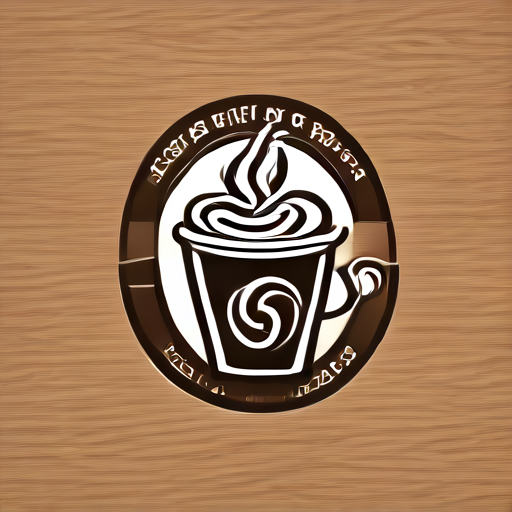

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

loser images:


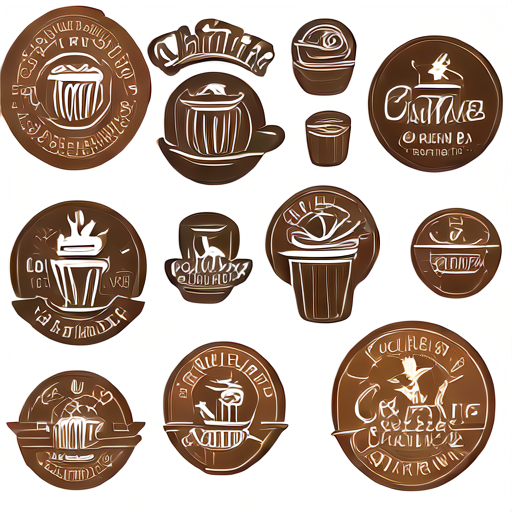

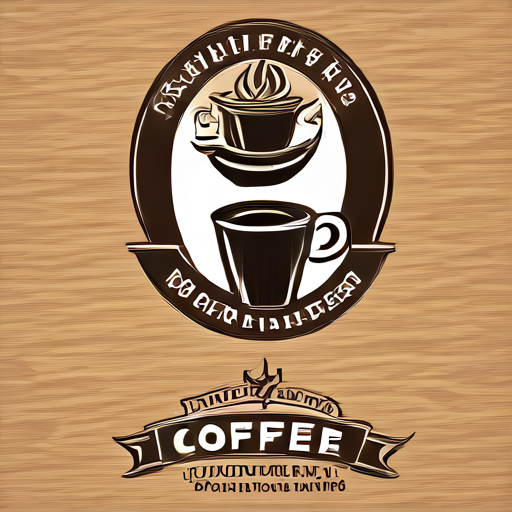

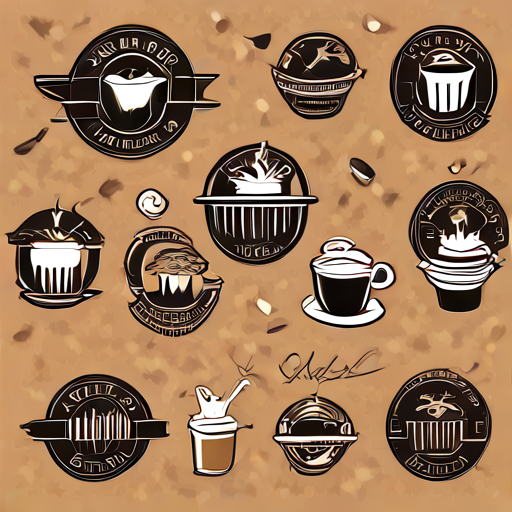

In [14]:
winner_image = pipe(
    prompt=example_prompt,
    num_images_per_prompt=1,
    latents=example_data_point.winner_latent.unsqueeze(0),
    width=512,
    height=512,
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]

# display
display(winner_image)

loser_images = [
    pipe(
        prompt=example_prompt,
        num_images_per_prompt=1,
        latents=loser_latent.unsqueeze(0),
        width=512,
        height=512,
        num_inference_steps=1,
        guidance_scale=0.0,
    ).images[0]
    for loser_latent in example_data_point.loser_latents
]

# display
print("loser images:")
for loser_image in loser_images:
    display(loser_image)


In [ ]:
# display the actual based on the example
example_rows = example_df[(example_df["round"] == example_round) & (example_df["trial_id"] == example_trial_id) & (example_df["prompt_id"] == example_prompt_id) & (example_df["alpha"] == example_alpha)]
winner_row = example_rows[example_rows["chosen"] == True]
loser_rows = example_rows[example_rows["chosen"] == False]

In [ ]:
loser_rows

In [ ]:
import PIL
from pathlib import Path
start_path = Path(f"results/latent_alpha={example_alpha}_10x10")

old_actual_winner_image_path: Path = Path(winner_row["image_path"].item())
# replace the first two parts of the path with start path
actual_winner_image_path: Path = start_path / Path(*old_actual_winner_image_path.parts[2:])

In [ ]:
# Load the image
actual_winner_image = PIL.Image.open(actual_winner_image_path)
display(actual_winner_image)

In [ ]:
# here's our design

